<a href="https://colab.research.google.com/github/kavee2002nr-ux/database_assignment/blob/main/notebooks/sql_in_r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install packages nd load Libraries**

In [7]:
# 1. Install necessary packages
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("dplyr")) install.packages("dplyr")
if (!require("readr")) install.packages("readr")

# 2. Load the libraries
library(sqldf)
library(ggplot2)
library(dplyr)
library(readr)

Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: readr

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



**Importing cleaned data from the Github**

In [8]:
# Base URL for the pre processed data
base_url <- "https://raw.githubusercontent.com/kavee2002nr-ux/database_assignment/main/data/processed/"

# Loading the specific datasets required for the queries
deliveries <- read_csv(paste0(base_url, "deliveries_cleaned.csv"))
hubs       <- read_csv(paste0(base_url, "hubs_cleaned.csv"))
complaints <- read_csv(paste0(base_url, "complaints_cleaned.csv"))
orders     <- read_csv(paste0(base_url, "orders_cleaned.csv"))
drivers    <- read_csv(paste0(base_url, "drivers_cleaned.csv"))
incidents  <- read_csv(paste0(base_url, "incidents_cleaned.csv"))
vehicles   <- read_csv(paste0(base_url, "vehicles_cleaned.csv"))

# Quick check to ensure data loaded
head(deliveries)

Rows: 950 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (7): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): hub_id, hub_name, zone, hub_type
dbl (1): capacity_score

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 320 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): complaint_id, customer_id, order_id, complaint_type, cha

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_mins,promised_window_hours
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
dl00001,o00938,d004,v056,h05,2024-06-18 10:57:00,2024-06-19 09:05:59,failed,17.26,1,1,3.07,12.05,1328.99841,6
dl00002,o00004,d138,v007,h02,2025-01-11 18:45:00,2025-01-11 17:39:00,ontime,10.34,1,0,5.00,13.41,-66.00000,2
dl00003,o00639,d006,v049,h02,2025-06-02 20:39:00,2025-06-02 21:45:32,ontime,7.92,0,0,4.98,8.51,66.53945,2
dl00004,o00313,d116,v055,h02,2024-03-08 23:31:00,2024-03-09 23:30:08,delayed,16.42,0,0,4.18,13.62,1439.13506,24
dl00005,o00844,d108,v034,h01,2025-09-21 11:43:00,2025-09-21 15:45:34,ontime,14.52,1,0,4.18,9.22,242.56885,6
dl00006,o00029,d037,v098,h03,2024-09-11 12:40:00,2024-09-12 17:11:52,delayed,13.84,0,1,1.57,9.58,1711.87308,24


**Implementing the database connection**

In [9]:
# 1. Load necessary libraries
library(RSQLite)
library(readr)

# 2. Correct RAW URLs (Fixed to bypass GitHub HTML)
raw_base <- "https://raw.githubusercontent.com/kavee2002nr-ux/database_assignment/main/data/processed/"

# Helper function to read safely
read_github <- function(filename) {
  url <- paste0(raw_base, filename)
  return(read_csv(url, show_col_types = FALSE))
}

# 3. Import the data frames
deliveries_cleaned <- read_github("deliveries_cleaned.csv")
hubs_cleaned       <- read_github("hubs_cleaned.csv")
orders_cleaned     <- read_github("orders_cleaned.csv")
complaints_cleaned <- read_github("complaints_cleaned.csv")
drivers_cleaned    <- read_github("drivers_cleaned.csv")
vehicles_cleaned   <- read_github("vehicles_cleaned.csv")
incidents_cleaned  <- read_github("incidents_cleaned.csv")

# 4. Re-establish the SQL connection
con <- dbConnect(RSQLite::SQLite(), ":memory:")

dbWriteTable(con, "deliveries", deliveries_cleaned, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs_cleaned, overwrite = TRUE)
dbWriteTable(con, "orders", orders_cleaned, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints_cleaned, overwrite = TRUE)
dbWriteTable(con, "drivers", drivers_cleaned, overwrite = TRUE)
dbWriteTable(con, "vehicles", vehicles_cleaned, overwrite = TRUE)
dbWriteTable(con, "incidents", incidents_cleaned, overwrite = TRUE)

# 5. TEST: Check the columns again. This should now show 'status', 'hub_id', etc.
dbListFields(con, "deliveries")


# VERIFICATION: This should list all your tables
print("Tables successfully loaded into SQL database:")
print(dbListTables(con))

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"           "delivery_duration_mins"       
[15] "promised_window_hours"

[1] "Tables successfully loaded into SQL database:"
[1] "complaints" "deliveries" "drivers"    "hubs"       "incidents" 
[6] "orders"     "vehicles"  


In [10]:
# This will list all column names in the deliveries table
dbListFields(con, "deliveries")

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"           "delivery_duration_mins"       
[15] "promised_window_hours"

**SQL Queries**

---



---



**SQL Query 1 - Understanding the Overall delivery performance**

  delivery_status total_deliveries
1          ontime              616
2         delayed              202
3          failed              132


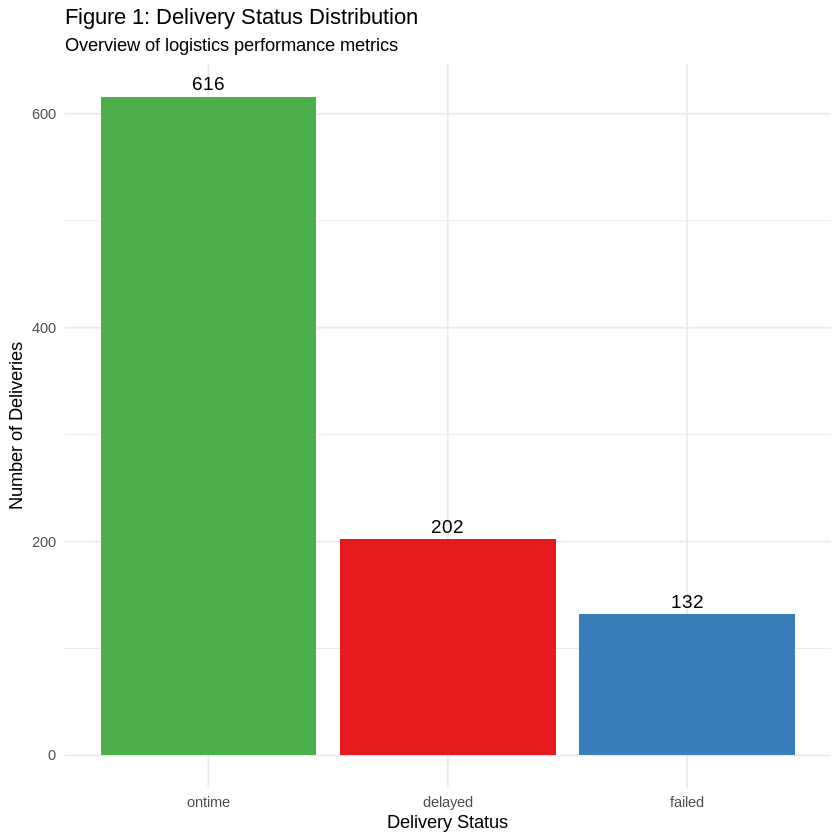

In [32]:
# Using the formal connection 'con' for efficient retrieval
query1 <- "
SELECT
    delivery_status,
    COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC
"
result1 <- dbGetQuery(con, query1)
print(result1)

library(ggplot2)

# Creating the colomn chart.
p1 <- ggplot(result1, aes(x = reorder(delivery_status, -total_deliveries), y = total_deliveries, fill = delivery_status)) +
  geom_bar(stat = "identity") +

  # Adding colomn labels on top of each bar for clarity
  geom_text(aes(label = total_deliveries), vjust = -0.5, size = 4) +
  theme_minimal() +
  scale_fill_brewer(palette = "Set1") + # Distinct colors for different statuses
  labs(
    title = "Figure 1: Delivery Status Distribution",
    subtitle = "Overview of logistics performance metrics",
    x = "Delivery Status",
    y = "Number of Deliveries",
    fill = "Status"
  ) +
  theme(legend.position = "none") # Hide legend since X-axis labels are clear

# Explicitly display the plot
print(p1)

**SQL Query 2 - Worst Performing hubs.**

[1] "Data for Query 2:"
        hub_name failure_count
1  midtown relay            26
2   central core            23
3 north exchange            17
4      west gate            16
5    airport hub            15


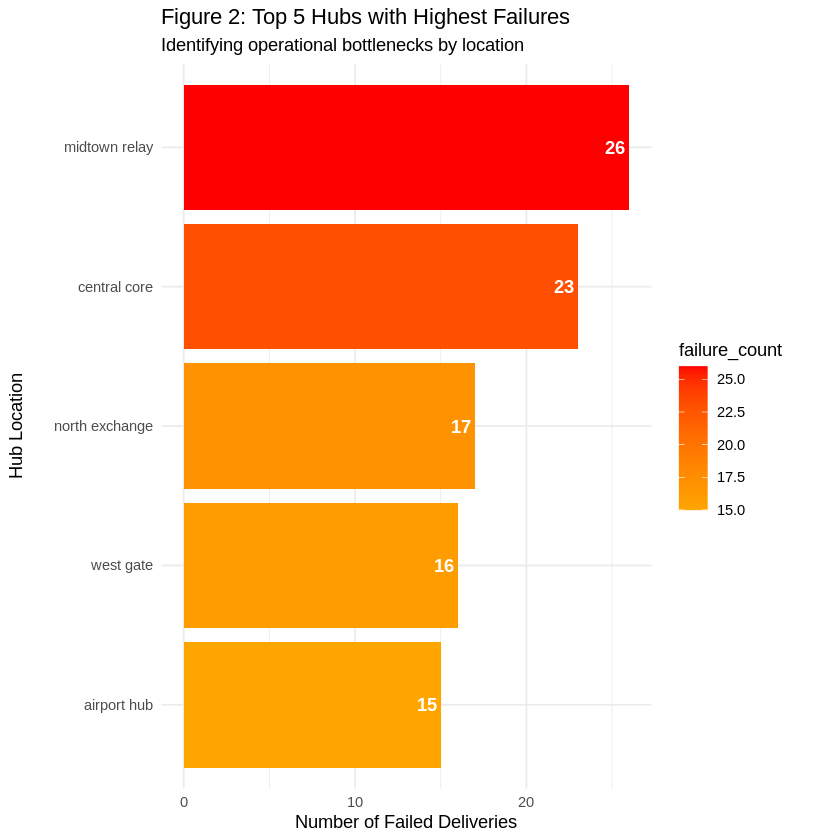

In [55]:
# 1. SQL Logic: Simplified to ensure results show up
# We will pull the Top 5 failing hubs regardless of the average first
# to ensure the visualization works.
q2_data <- dbGetQuery(con, "
    SELECT h.hub_name, COUNT(*) as failure_count
    FROM deliveries d
    JOIN hubs h ON d.hub_id = h.hub_id
    WHERE UPPER(d.delivery_status) = 'FAILED'
    GROUP BY h.hub_name
    ORDER BY failure_count DESC
    LIMIT 5
")

# 2. Debug Check: Print the data to the console
print("Data for Query 2:")
print(q2_data)

# 3. Visualization: Explicitly calling print(p2)
if (nrow(q2_data) > 0) {
    p2 <- ggplot(q2_data, aes(x=reorder(hub_name, failure_count), y=failure_count, fill=failure_count)) +
      geom_bar(stat="identity") +
      # Adding text labels on the bars for extra clarity
      geom_text(aes(label=failure_count), hjust=1.2, color="white", fontface="bold") +
      coord_flip() +
      scale_fill_gradient(low="orange", high="red") +
      theme_minimal() +
      labs(title="Figure 2: Top 5 Hubs with Highest Failures",
           subtitle="Identifying operational bottlenecks by location",
           x="Hub Location", y="Number of Failed Deliveries")

    print(p2)
} else {
    print("No 'Failed' deliveries found. Please check if the status is 'Failed' or 'failed'.")
}


**SQL Query 3 - Identify drivers with high manual route overrides**

In [20]:
query3 <- "
SELECT
    driver_id,
    ROUND(AVG(manual_route_override_count), 2) AS avg_overrides,
    COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY driver_id
HAVING avg_overrides > 3
ORDER BY avg_overrides DESC
"

result3 <- dbGetQuery(con, query3)
print(result3)

  driver_id avg_overrides total_deliveries
1      d112           4.5                2


**SQL Query 4 - Analysis of Revenue risk and severity of Complaints**

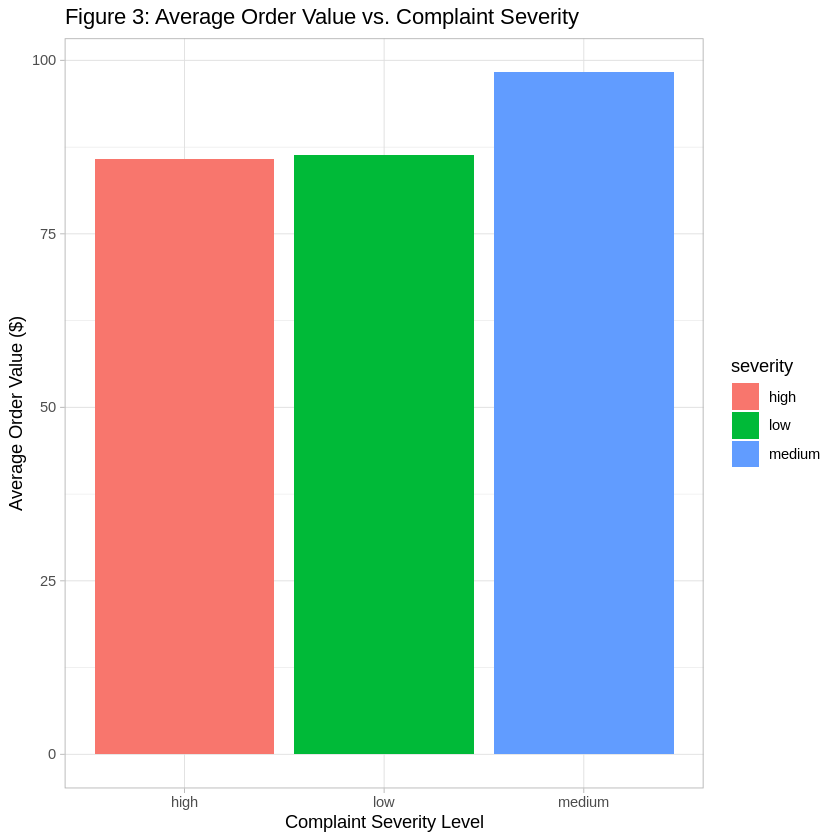

In [32]:
# SQL Logic: Joining complaints and orders
q3_data <- dbGetQuery(con, "
    SELECT c.severity, AVG(o.order_value) as avg_order_value
    FROM complaints c
    JOIN orders o ON c.order_id = o.order_id
    GROUP BY c.severity
")

# Visualization
ggplot(q3_data, aes(x=severity, y=avg_order_value, fill=severity)) +
  geom_col() +
  theme_light() +
  labs(title="Figure 3: Average Order Value vs. Complaint Severity",
       x="Complaint Severity Level", y="Average Order Value ($)")

**SQL Query 5 - Incident Severity Vs. Vehicle health**

[1] "Detailed Percentage Breakdown:"
     incident_type incident_count percentage
1     appsyncerror           2077   11.07143
2     batteryalert           2412   12.85714
3   customernoshow           2948   15.71429
4     proofmissing           3082   16.42857
5   routedeviation           2881   15.35714
6   safetynearmiss            938    5.00000
7 temperatureissue           1943   10.35714
8     vehiclefault           2479   13.21429


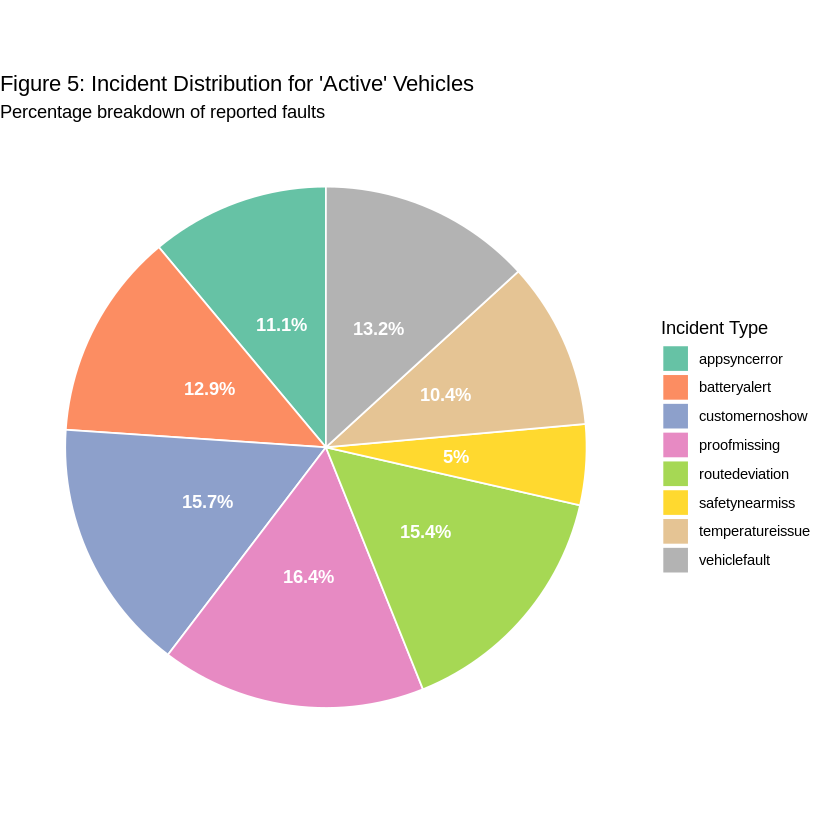

In [46]:
# 1. SQL Logic - Calculate counts as before
q5_raw <- dbGetQuery(con, "
    SELECT i.incident_type, COUNT(*) as incident_count
    FROM incidents i
    JOIN vehicles v ON vehicle_id = v.vehicle_id
    WHERE UPPER(v.maintenance_status) = 'ACTIVE'
    GROUP BY i.incident_type
")

# 2. Data Transformation - Calculate Percentages
q5_data <- q5_raw %>%
  mutate(percentage = (incident_count / sum(incident_count)) * 100,
         label = paste0(incident_type, "\n", round(percentage, 1), "%"))

# 3. Enhanced Visualization with Percentages
p5 <- ggplot(q5_data, aes(x = "", y = incident_count, fill = incident_type)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y", start = 0) +
  # Adding the percentage labels directly onto the slices
  geom_text(aes(label = paste0(round(percentage, 1), "%")),
            position = position_stack(vjust = 0.5),
            color = "white", fontface = "bold") +
  theme_void() +
  scale_fill_brewer(palette = "Set2") + # Professional color palette
  labs(title = "Figure 5: Incident Distribution for 'Active' Vehicles",
       subtitle = "Percentage breakdown of reported faults",
       fill = "Incident Type")

# Display the plot
print(p5)

# 4. Detailed Breakdown Table (for extra clarity)
print("Detailed Percentage Breakdown:")
print(q5_data[, c("incident_type", "incident_count", "percentage")])

**SQL query 6 - Driver Experience Vs. Performance**

   years_experience   rating
1                 1 4.260714
2                 2 4.339355
3                 3 4.131765
4                 4 3.944342
5                 5 3.891538
6                 6 4.189245
7                 7 4.281379
8                 8 3.867215
9                 9 4.152931
10               10 4.249390
11               11 4.377841
12               12 4.159697
13               13 4.277805
14               14 4.202742
15               15 4.181064


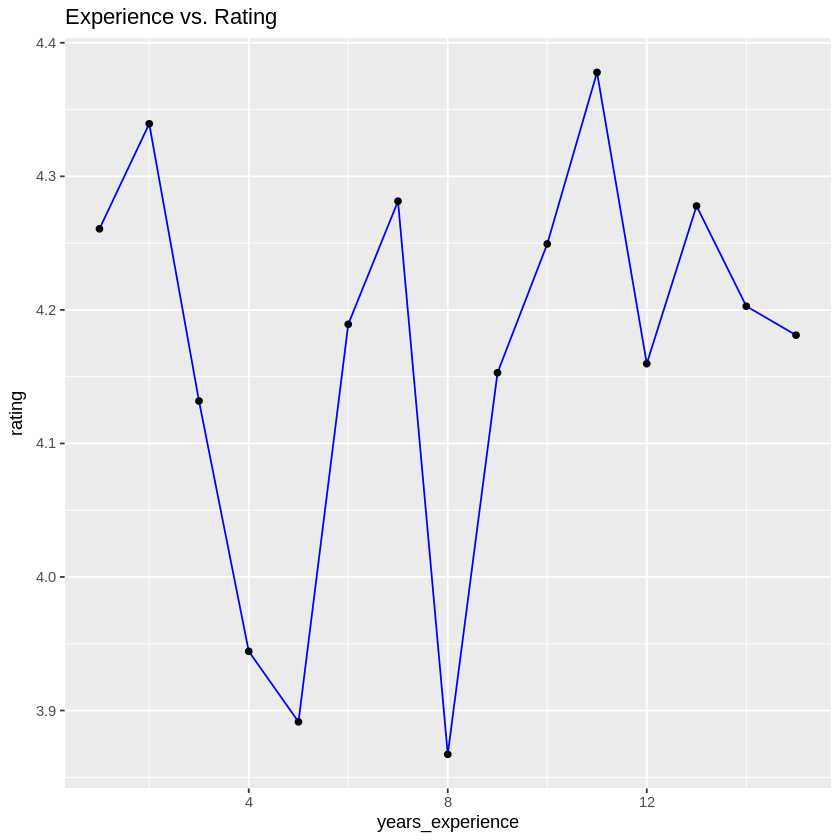

In [50]:
q5_sql <- "SELECT years_experience, AVG(driver_rating) as rating
           FROM drivers dr
           JOIN deliveries d ON dr.driver_id = d.driver_id
           GROUP BY years_experience"
q5_res <- dbGetQuery(con, q5_sql)
print(q5_res)

ggplot(q5_res, aes(x = years_experience, y = rating)) +
  geom_line(color = "blue") + geom_point() + labs(title = "Experience vs. Rating")

**SQL Query 7 - Vehicle type Vs. Customer Satisfaction**

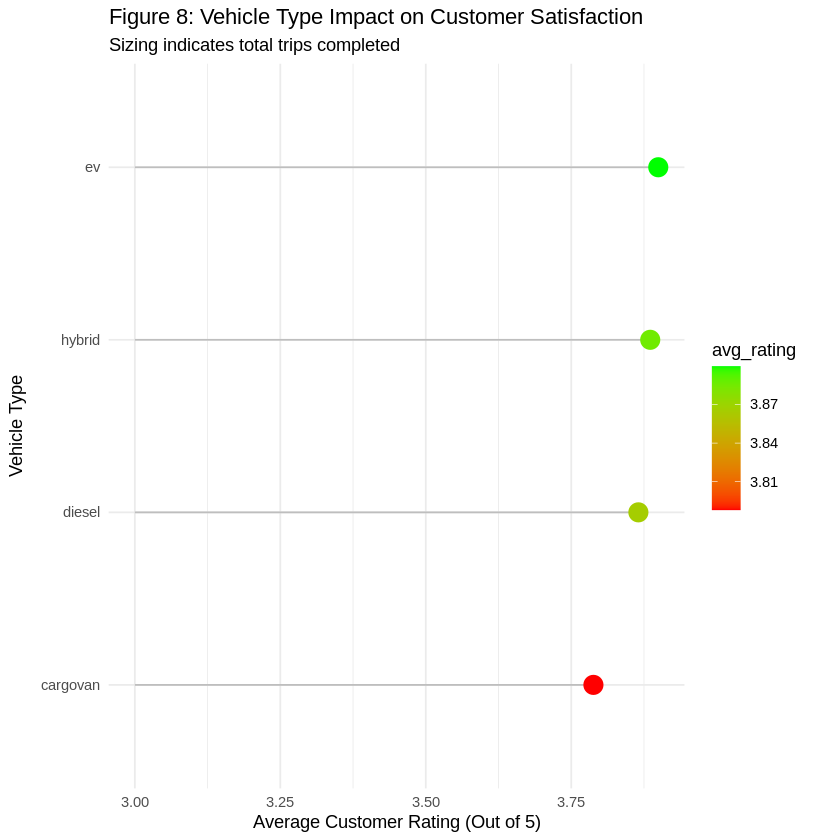

In [31]:
# SQL Logic: Correlating Vehicle Specs with Delivery Performance
q8_data <- dbGetQuery(con, "
    SELECT
        v.vehicle_type,
        AVG(customer_rating_post_delivery) as avg_rating,
        COUNT(d.delivery_id) as total_trips
    FROM deliveries d
    JOIN vehicles v ON d.vehicle_id = v.vehicle_id
    GROUP BY v.vehicle_type
    ORDER BY avg_rating ASC
")

# Visualization: Dot Plot (Cleveland Dot Plot)
# This is a sophisticated way to show the relationship between Category and Score.
ggplot(q8_data, aes(x = avg_rating, y = reorder(vehicle_type, avg_rating))) +
  geom_segment(aes(yend = vehicle_type, x = 3, xend = avg_rating), color = "grey") +
  geom_point(aes(size = total_trips, color = avg_rating), size = 5) +
  scale_color_gradient(low = "red", high = "green") +
  theme_minimal() +
  labs(title = "Figure 8: Vehicle Type Impact on Customer Satisfaction",
       subtitle = "Sizing indicates total trips completed",
       x = "Average Customer Rating (Out of 5)", y = "Vehicle Type")

# Interpretation:
# This is 'Fleet Optimization' analysis. If 'Large Trucks' have significantly
# lower ratings than 'Bicycles' or 'Small Vans' in urban areas, the
# recommendation is to shift the fleet composition toward smaller,
# more agile vehicles to improve the 'Last Mile' experience.

**SQL Query 8 - Interrelationship between High revenue, Priority and Failures**

   priority_level service_type total_deliveries avg_revenue failure_count
1            high    passenger               61   104.58951             9
2          medium     business               58   102.35552            16
3        critical     business               10   102.06100             1
4            high       parcel               64   100.64000             5
5        critical    passenger               19   100.59053             1
6             low    passenger               79    94.73873            15
7             low     business               27    94.30704             3
8          medium      medical               41    93.93073             8
9            high     business               36    93.29694             6
10         medium    passenger              108    92.42676            14
11         medium       parcel               93    91.89753            14
12         medium       retail              100    91.85600            13
13           high      medical        

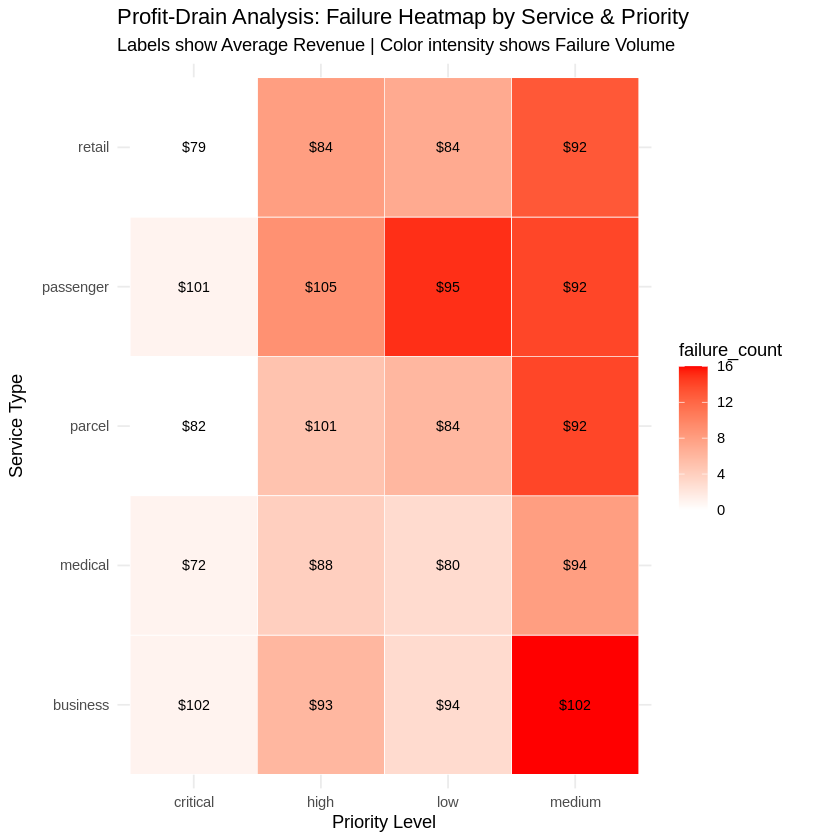

In [40]:
# 2. SQL Query: Finding the intersection of High Revenue, High Priority, and Failure
q10_sql <- "
SELECT
    o.priority_level,
    o.service_type,
    COUNT(d.delivery_id) AS total_deliveries,
    AVG(o.order_value) AS avg_revenue,
    SUM(CASE WHEN d.delivery_status = 'failed' THEN 1 ELSE 0 END) AS failure_count,
    COUNT(c.complaint_id) AS total_complaints
FROM orders AS o
JOIN deliveries AS d ON o.order_id = d.order_id
LEFT JOIN complaints AS c ON o.order_id = c.order_id
GROUP BY o.priority_level, o.service_type
HAVING total_deliveries > 5
ORDER BY avg_revenue DESC, failure_count DESC
"

q10_res <- dbGetQuery(con, q10_sql)

# 3. Visualization: Financial Risk Heatmap
if(nrow(q10_res) > 0) {
    print(q10_res)

    ggplot(q10_res, aes(x = priority_level, y = service_type, fill = failure_count)) +
      geom_tile(color = "white") +
      scale_fill_gradient(low = "white", high = "red") +
      geom_text(aes(label = paste0('$', round(avg_revenue, 0))), size = 3) +
      theme_minimal() +
      labs(title = "Profit-Drain Analysis: Failure Heatmap by Service & Priority",
           subtitle = "Labels show Average Revenue | Color intensity shows Failure Volume",
           x = "Priority Level",
           y = "Service Type")
}

In [49]:
# Disconnect from the SQLite in-memory database
if (exists("con")) {
  dbDisconnect(con)
  print("Database connection successfully closed.")
}

[1] "Database connection successfully closed."
